# AI CPR Guardian

### A wall-mounted unit that coaches an untrained bystander through chest compressions

Someone collapses in a classroom, an office, a railway station, a block of flats. Nobody
nearby is medically trained. The helper pulls a unit off the wall containing a **camera**,
a **speaker and display**, a **CPR pressure pad**, an **AED**, an **emergency-call link**
and **red / amber / green lights**.

The helper has never done this before, and the next four minutes decide the outcome.

---

## ⚠️ Read this before anything else

This notebook is a **teaching simulation built on synthetic data**. It is not a medical
device, it has not been tested on a person, and nothing in it may be used to guide real
resuscitation. Every number below comes from a generator written further down this page —
no patient, helper or mannequin was recorded.

If you build the real thing, it is a regulated medical device. Get it regulated.

---

## The engineering correction that shapes the whole design

The obvious design is "point a camera at the helper and measure everything". That design
is wrong, and it is worth being precise about why.

| Question | Sensor that should answer it | Why not the other one |
|---|---|---|
| Is the helper's posture right? | **Camera** | A pad cannot see arms, shoulders or a second helper |
| How deep is each compression? | **Pressure / displacement pad** | A camera measures *pixels*, and converting pixels to centimetres of chest travel depends on lens, angle, distance, clothing and body size. A 20% error here is the difference between effective and useless CPR |
| How fast, and does the chest recoil? | **Pressure / displacement pad** | Same reason — this is a physical displacement question |
| Is this rhythm shockable? | **AED** | This is the AED's regulated function |
| **Should a shock be delivered?** | **The AED. Only ever the AED.** | The coaching AI must never make, override or influence this decision |

So the split this notebook implements is:

- **Camera → posture.** Elbow angle, shoulders over hands, hand placement, has the helper
  stopped, is a second person available.
- **Pad → mechanics.** Depth, rate, recoil, excessive force.
- **AED → rhythm.** The notebook models only the *stand-clear state* the coach must enforce
  around it. It never decides anything about a shock.

Real-time CPR feedback devices that report rate, depth and recoil are established practice,
and audiovisual feedback is considered reasonable for optimising CPR performance.
Computer-vision posture feedback is a newer and less settled research area — which is
exactly why it is kept off the depth measurement here.

---

## What this notebook does

1. Simulates a whole 3½-minute rescue — two helpers, one AED pause, one honest case of fatigue
2. Turns camera keypoints into **elbow angle** and **shoulder-over-hands** alignment
3. Reads the simulated pad and **counts compressions** by finding peaks
4. Measures **depth, rate and recoil** for every single compression
5. Applies the **feedback rules** and decides what the unit should say, one message at a time
6. Detects **declining performance** and calls for a **rescuer switch**
7. Enforces the **AED stand-clear** state
8. Draws the **final CPR-quality timeline**

🎬 **See it illustrated:** step 14 — *The One Decision The AI Must Not Make*, step 8 — *The Number Between The Peaks*, step 2 — *Camera, Pad Or AED?* in the illustration tab.


🎬 **The illustrated version.**

[Open the AI CPR Guardian illustration app once, in a second tab](https://cpr-guardian-ai.streamlit.app/?stage=start), and leave it open beside this notebook.

Each section below says which **step** to show over there. Move that tab with the **◀ ▶** buttons at the foot of its page, or jump straight to any step from the **Learning journey** list on its front page. Opening it once keeps you at two tabs: Colab gives every link click a brand-new one.


## 1. Setup

Only numpy, pandas and matplotlib. The peak finder is written by hand rather than imported,
because seeing how compressions get counted is half the lesson.

🎬 **See it illustrated:** step 1 — *Nobody Here Is Trained* in the illustration tab.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)

FS = 50                      # samples per second from the pad and the camera
RESCUE_SECONDS = 210         # 3 minutes 30

# Guideline targets for an adult. These are the numbers every threshold below refers to.
DEPTH_MIN, DEPTH_MAX = 5.0, 6.0      # centimetres
RATE_MIN, RATE_MAX = 100, 120        # compressions per minute
RECOIL_MAX = 0.5                     # cm still pressed in at full release
SWITCH_SECONDS = 120                 # swap rescuers about every 2 minutes

print(f"{FS} Hz · {RESCUE_SECONDS} s · {FS * RESCUE_SECONDS} samples per signal")

50 Hz · 210 s · 10500 samples per signal


## 2. Simulating the rescue

Real training data would come from a mannequin. Here the session is generated, so that every
problem the unit must catch is present *on purpose* and we know the right answer.

**The story the generator tells:**

| Time | What is happening |
|---|---|
| 0 – 7 s | Helper arrives, unit powers up. No compressions yet. |
| 7 – 100 s | **Rescuer A.** Starts well. From about a minute in, tires: presses shallower, drifts faster, starts leaning on the chest between compressions and lets the elbows bend. |
| 100 – 112 s | **AED analysing, then a shock.** Nobody may touch the patient. |
| 112 – 210 s | **Rescuer B**, fresh. Good depth, but starts far too slow — until the metronome pulls them up. |

Two different failure modes on purpose: A degrades *gradually* (which is hard to notice from
inside), B is wrong *immediately* in a single measurement (which is easy to fix once told).

🎬 **See it illustrated:** step 3 — *Three And A Half Minutes*, step 4 — *What The Pad Feels* in the illustration tab.


In [2]:
def ramp(t, points):
    """Piecewise-linear control curve: points is [(time, value), ...]."""
    times = [p[0] for p in points]
    values = [p[1] for p in points]
    return np.interp(t, times, values)


t = np.arange(0, RESCUE_SECONDS, 1 / FS)

# ---- who is compressing, and when ------------------------------------------
HANDS_OFF = [(0, 7), (100, 112)]          # arrival, then the AED pause
compressing = np.ones_like(t, dtype=bool)
for start, end in HANDS_OFF:
    compressing[(t >= start) & (t < end)] = False

rescuer = np.where(t < 106, "A", "B")
rescuer[~compressing] = "-"

# ---- what each rescuer's technique does over time ---------------------------
# amplitude (cm), rate (per minute), lean left on the chest (cm), elbow angle (deg),
# shoulders ahead of hands (cm), hands off the sternum centre (cm)
amp = np.where(t < 106,
               ramp(t, [(7, 5.4), (55, 5.2), (80, 4.5), (100, 3.9)]),      # A tires
               ramp(t, [(112, 5.6), (210, 5.2)]))                          # B steady
rate = np.where(t < 106,
                ramp(t, [(7, 112), (55, 114), (100, 126)]),                # A speeds up
                ramp(t, [(112, 96), (145, 97), (165, 110), (210, 112)]))   # B slow, corrected
lean = np.where(t < 106,
                ramp(t, [(7, 0.10), (55, 0.15), (100, 0.95)]),             # A leans when tired
                ramp(t, [(112, 0.12), (210, 0.18)]))
elbow = np.where(t < 106,
                 ramp(t, [(7, 178), (55, 176), (100, 156)]),               # A's arms bend
                 ramp(t, [(112, 168), (135, 177), (210, 177)]))            # B corrects early
shoulder_off = np.where(t < 106,
                        ramp(t, [(7, 1.0), (55, 1.5), (100, 6.5)]),
                        ramp(t, [(112, 2.0), (210, 2.4)]))
hand_off = np.where(t < 106,
                    ramp(t, [(7, 0.5), (55, 0.9), (100, 3.2)]),            # A's hands wander
                    ramp(t, [(112, 0.8), (210, 1.1)]))

print(f"hands-off windows: {HANDS_OFF}")
print(f"rescuer A: {(rescuer == 'A').sum() / FS:.0f} s   "
      f"rescuer B: {(rescuer == 'B').sum() / FS:.0f} s   "
      f"hands off: {(~compressing).sum() / FS:.0f} s")

hands-off windows: [(0, 7), (100, 112)]
rescuer A: 93 s   rescuer B: 98 s   hands off: 19 s


### 2.1 The pad signal

A compression is one push-and-release. The generator advances a **phase** at the current rate
and turns that phase into a depth. The important detail is `lean`: the depth the chest is
*still* pressed in at the moment of full release. When that stops returning to zero, the heart
cannot refill — which is why "release fully" is one of the messages the unit has to say.

In [3]:
rng = np.random.default_rng(11)

phase = np.zeros_like(t)
for i in range(1, len(t)):
    step = 2 * np.pi * (rate[i] / 60.0) / FS if compressing[i] else 0.0
    phase[i] = phase[i - 1] + step

# 0 at full release, 1 at the bottom of the push
push = (1 - np.cos(phase)) / 2
depth = np.where(compressing, lean + amp * push, 0.0)
depth += rng.normal(0, 0.03, len(t))            # pad noise
depth = np.clip(depth, 0, None)

pad = pd.DataFrame({"t": t, "depth_cm": depth, "compressing": compressing,
                    "rescuer": rescuer})
print(pad.head())
print(f"\ndeepest single push: {pad.depth_cm.max():.2f} cm")

      t  depth_cm  compressing rescuer
0  0.00  0.001026        False       -
1  0.02  0.040792        False       -
2  0.04  0.036742        False       -
3  0.06  0.000000        False       -
4  0.08  0.000000        False       -

deepest single push: 5.75 cm


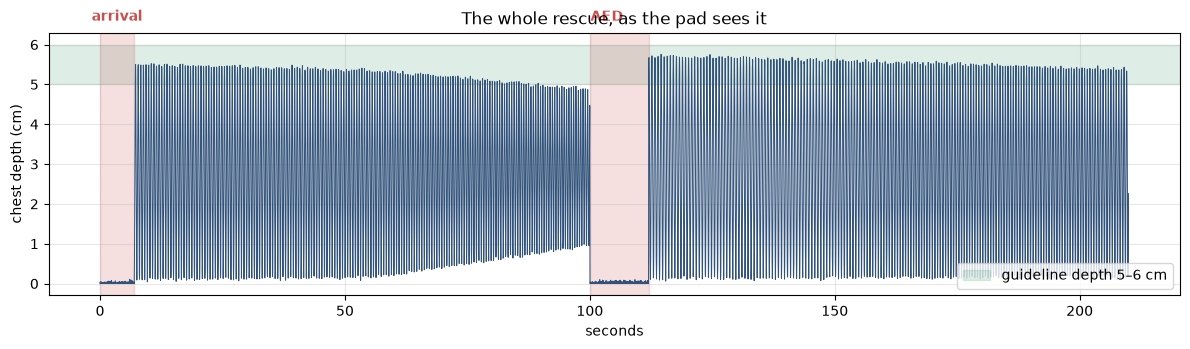

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.axhspan(DEPTH_MIN, DEPTH_MAX, color="#4c9f70", alpha=0.18, label="guideline depth 5–6 cm")
ax.plot(pad.t, pad.depth_cm, lw=0.7, color="#31527a")
for start, end in HANDS_OFF:
    ax.axvspan(start, end, color="#c94f4f", alpha=0.18)
ax.text(103.5, 6.6, "AED", ha="center", color="#c94f4f", fontweight="bold")
ax.text(3.5, 6.6, "arrival", ha="center", color="#c94f4f", fontweight="bold")
ax.set_xlabel("seconds"); ax.set_ylabel("chest depth (cm)")
ax.set_title("The whole rescue, as the pad sees it")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

At this zoom every compression is a single vertical stroke. To see what the unit actually reasons about, we have to zoom in.

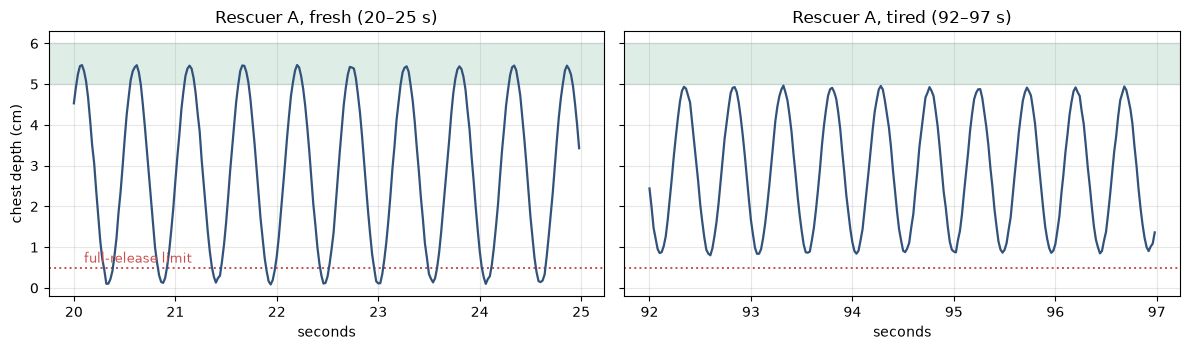

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (lo, hi), title in zip(axes, [(20, 25), (92, 97)],
                               ["Rescuer A, fresh (20–25 s)", "Rescuer A, tired (92–97 s)"]):
    part = pad[(pad.t >= lo) & (pad.t < hi)]
    ax.axhspan(DEPTH_MIN, DEPTH_MAX, color="#4c9f70", alpha=0.18)
    ax.axhline(RECOIL_MAX, color="#c94f4f", ls=":", lw=1.4)
    ax.plot(part.t, part.depth_cm, color="#31527a", lw=1.6)
    ax.set_title(title); ax.set_xlabel("seconds")
axes[0].set_ylabel("chest depth (cm)")
axes[0].text(20.1, RECOIL_MAX + 0.12, "full-release limit", color="#c94f4f", fontsize=9)
plt.tight_layout(); plt.show()

Read the two panels against each other. On the right the peaks are **lower** (shallower
compressions), they are **closer together** (faster), and the troughs no longer come back down
to the floor — the helper is **resting their weight on the chest between pushes**.

That is one tired person, five minutes into the worst day of someone's life. They cannot feel
it happening. That is the entire reason the unit exists.

## 3. What the camera sees

The camera contributes **posture**, not depth. A pose model returns keypoints — shoulder,
elbow, wrist, hip — as coordinates. Everything below is arithmetic on those coordinates.

Here the keypoints are generated *from* the technique curves, with camera jitter added, so
that the angle we compute can be checked against the angle we asked for.

🎬 **See it illustrated:** step 5 — *What The Camera Sees*, step 6 — *The Angle At The Elbow* in the illustration tab.


In [6]:
ARM_CM = 58.0        # shoulder-to-wrist, this helper

def build_keypoints(elbow_deg, shoulder_offset, hand_offset, chest_depth, jitter=0.4, seed=3):
    """Return wrist / elbow / shoulder positions in centimetres, camera plane.

    x = sideways across the patient's chest, 0 = centre of the sternum
    y = height above the chest, so pressing down lowers everything
    """
    noise = np.random.default_rng(seed)
    wrist = np.stack([hand_offset, -chest_depth], axis=1)

    dx = np.clip(shoulder_offset, -ARM_CM + 1, ARM_CM - 1)
    shoulder = np.stack([wrist[:, 0] + dx,
                         wrist[:, 1] + np.sqrt(ARM_CM ** 2 - dx ** 2)], axis=1)

    # place the elbow off the shoulder-wrist line so that the angle at the elbow
    # comes out at elbow_deg: offset = (L/2) / tan(angle/2)
    half = ARM_CM / 2
    offset = half / np.tan(np.radians(elbow_deg) / 2)
    along = (shoulder - wrist)
    along /= np.linalg.norm(along, axis=1, keepdims=True)
    perp = np.stack([-along[:, 1], along[:, 0]], axis=1)
    elbow = (wrist + shoulder) / 2 + perp * offset[:, None]

    for arr in (wrist, elbow, shoulder):
        arr += noise.normal(0, jitter, arr.shape)
    return wrist, elbow, shoulder


wrist, elbow_pt, shoulder = build_keypoints(elbow, shoulder_off, hand_off, depth)
print("keypoint arrays:", wrist.shape, elbow_pt.shape, shoulder.shape)
print("wrist at t=20s:", wrist[20 * FS].round(2))

keypoint arrays: (10500, 2) (10500, 2) (10500, 2)
wrist at t=20s: [ 0.62 -4.91]


### 3.1 Elbow angle from three points

The angle at the elbow is the angle between "elbow → shoulder" and "elbow → wrist". Straight
arms are close to 180°. This is the single most useful posture number, because bent arms mean
the helper is pushing with their **arms** instead of dropping their **body weight** — which is
both weaker and exhausting.

In [7]:
def angle_at(b, a, c):
    """Angle in degrees at point b, formed by a-b-c. Works on arrays of points."""
    v1, v2 = a - b, c - b
    cosine = ((v1 * v2).sum(axis=1) /
              (np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1)))
    return np.degrees(np.arccos(np.clip(cosine, -1, 1)))


elbow_measured = angle_at(elbow_pt, shoulder, wrist)

# a moving average, because raw keypoints are jittery
def smooth(x, seconds=0.6):
    w = max(1, int(seconds * FS))
    return pd.Series(x).rolling(w, center=True, min_periods=1).mean().to_numpy()


elbow_smooth = smooth(elbow_measured)

print(f"asked for : {elbow[20 * FS]:.1f}°   measured raw: {elbow_measured[20 * FS]:.1f}°   "
      f"smoothed: {elbow_smooth[20 * FS]:.1f}°")
print(f"typical error before smoothing: {np.abs(elbow_measured - elbow).mean():.2f}°")
print(f"typical error after smoothing : {np.abs(elbow_smooth - elbow).mean():.2f}°")

asked for : 177.5°   measured raw: 175.2°   smoothed: 177.2°
typical error before smoothing: 1.46°
typical error after smoothing : 0.29°


That comparison is the point of the cell. Camera jitter of a few millimetres per keypoint
turns into **degrees** of angle error, because the elbow sits nearly on a straight line and a
small sideways wobble swings the angle a long way. Smoothing costs a little lag and buys back
most of the accuracy.

It is also a preview of why depth must not come from the camera: if a 4 mm keypoint wobble
moves the elbow angle by degrees, the same wobble is a large fraction of a 5 cm compression.

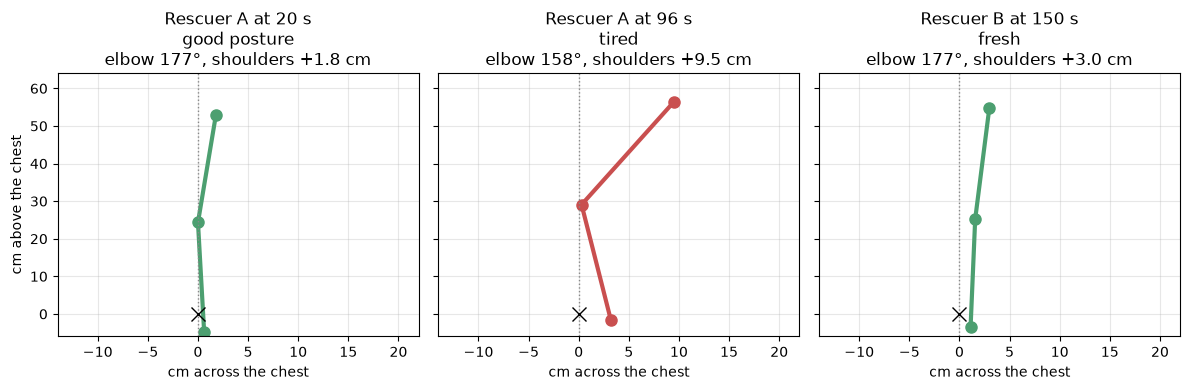

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, moment, title in zip(axes, [20, 96, 150],
                             ["Rescuer A at 20 s\ngood posture",
                              "Rescuer A at 96 s\ntired",
                              "Rescuer B at 150 s\nfresh"]):
    i = moment * FS
    pts = np.stack([wrist[i], elbow_pt[i], shoulder[i]])
    good = elbow_smooth[i] >= 165
    colour = "#4c9f70" if good else "#c94f4f"
    ax.plot(pts[:, 0], pts[:, 1], "-o", color=colour, lw=3, markersize=8)
    ax.axvline(0, color="#888", ls=":", lw=1)
    ax.plot(0, 0, "kx", markersize=10)
    ax.set_title(f"{title}\nelbow {elbow_smooth[i]:.0f}°, shoulders {shoulder[i, 0]:+.1f} cm")
    ax.set_xlim(-14, 22); ax.set_ylim(-6, 64)
    ax.set_xlabel("cm across the chest")
axes[0].set_ylabel("cm above the chest")
plt.tight_layout(); plt.show()

The cross marks the centre of the sternum, where the hands belong. The dotted line is straight up from it: with good technique the shoulder sits on that line, directly over the hands, so the helper's weight does the work.

## 4. Counting compressions

Everything the unit says is *per compression*, so first we have to find them. A compression is
a **local maximum** of the depth signal: deeper than its neighbours, past a minimum depth to
count as a push at all, and far enough from the previous one that we do not count the same push
twice.

Three lines of rule, no library.

🎬 **See it illustrated:** step 7 — *Counting The Pushes* in the illustration tab.


In [9]:
def find_compressions(depth, fs=FS, min_depth=1.5, min_gap_s=0.25):
    """Indices of the bottom of each compression."""
    gap = int(min_gap_s * fs)
    higher_than_neighbours = (depth[1:-1] > depth[:-2]) & (depth[1:-1] >= depth[2:])
    candidates = np.where(higher_than_neighbours & (depth[1:-1] > min_depth))[0] + 1

    peaks = []
    for i in candidates:
        if not peaks or i - peaks[-1] >= gap:
            peaks.append(i)
        elif depth[i] > depth[peaks[-1]]:       # keep the deeper of two close candidates
            peaks[-1] = i
    return np.array(peaks)


peaks = find_compressions(pad.depth_cm.to_numpy())
print(f"{len(peaks)} compressions found")
print(f"time actually compressing: {compressing.sum() / FS:.0f} s")
print(f"average rate over that time: {len(peaks) / (compressing.sum() / FS) * 60:.0f} per minute")

352 compressions found
time actually compressing: 191 s
average rate over that time: 111 per minute


### 4.1 Full release: the number between the peaks

Depth at the peak is only half the story. Between two pushes the chest must come **all the way
back**, or it cannot refill with blood. So for every compression we also record the *shallowest*
point before the next one — the residual depth the helper is still leaning on.

In [10]:
rows = []
for n, p in enumerate(peaks):
    nxt = peaks[n + 1] if n + 1 < len(peaks) else len(pad) - 1
    trough = pad.depth_cm.to_numpy()[p:nxt + 1].min() if nxt > p else 0.0
    gap_s = (peaks[n + 1] - p) / FS if n + 1 < len(peaks) else np.nan
    rows.append(dict(
        n=n + 1,
        t=pad.t.to_numpy()[p],
        depth_cm=pad.depth_cm.to_numpy()[p],
        residual_cm=trough,
        rate_cpm=60 / gap_s if gap_s and gap_s > 0 else np.nan,
        rescuer=pad.rescuer.to_numpy()[p],
        elbow_deg=elbow_smooth[p],
        shoulder_cm=abs(shoulder[p, 0] - wrist[p, 0]),
        hand_cm=abs(wrist[p, 0]),
    ))

comp = pd.DataFrame(rows)
# the gap after the last compression before a pause is not a rate, it is a pause
comp.loc[comp.rate_cpm < 40, "rate_cpm"] = np.nan

# how far the chest actually travelled on this push, as opposed to how far down it got
comp["stroke_cm"] = comp.depth_cm - comp.residual_cm

comp.head(8).round(2)

,n,t,depth_cm,residual_cm,rate_cpm,rescuer,elbow_deg,shoulder_cm,hand_cm,stroke_cm
0,1,7.26,5.50,0.09,111.11,A,177.50,1.08,0.08,5.41
1,2,7.80,5.49,0.11,115.38,A,178.05,0.73,0.63,5.39
2,3,8.32,5.49,0.09,115.38,A,177.47,1.00,0.44,5.40
3,4,8.84,5.48,0.10,111.11,A,177.60,0.37,1.02,5.39
4,5,9.38,5.50,0.04,107.14,A,177.40,0.65,1.23,5.45
5,6,9.94,5.48,0.14,115.38,A,177.69,1.63,0.20,5.35
6,7,10.46,5.52,0.13,111.11,A,177.95,1.91,0.09,5.39
7,8,11.00,5.52,0.11,115.38,A,177.36,1.63,0.08,5.40


In [11]:
comp.groupby("rescuer")[["depth_cm", "stroke_cm", "residual_cm",
                         "rate_cpm", "elbow_deg"]].mean().round(2)

,depth_cm,stroke_cm,residual_cm,rate_cpm,elbow_deg
rescuer,,,,,
A,5.27,4.93,0.34,116.71,171.31
B,5.55,5.40,0.15,105.05,175.92


**`depth_cm` and `stroke_cm` are not the same number, and the gap between them is the most
important thing on this page.**

- `depth_cm` — how far down the chest got. This is what the guidelines mean by depth, and what
  the pad reports.
- `stroke_cm` — how far the chest actually *travelled* on that push: peak minus the point it
  started from.

They are equal only when the helper releases fully. Rescuer A does not, so A's chest still
reaches roughly the right depth while each individual push does progressively less work. Section
6 is where that matters.

Two rescuers, two different failures, and **neither session average looks disastrous** — which
is exactly why the unit works compression by compression instead of reporting means.

## 5. From measurement to feedback

Now the table from the specification, as code.

| What the unit observes | What it does |
|---|---|
| Hands off the centre of the chest | Red hand-location marker on the display |
| Compression too shallow | Red light, "press deeper" |
| Incomplete recoil | "Release fully" |
| Too slow | Faster audio beat |
| Too fast | Slower audio beat |
| Elbows bent | "Straighten your arms" |
| Shoulders not above hands | "Move your shoulders forward" |
| Excessive force | "Ease off" |
| Everything correct | Green light, steady beat |

**One message at a time.** This is a design decision, not a technical limitation. A panicking
untrained helper given four instructions at once follows none of them. The rules are therefore
ordered by how much each one costs the patient, and only the first one that fires is spoken.
Depth and recoil move blood; a bent elbow only makes the helper tire sooner.

🎬 **See it illustrated:** step 9 — *One Message At A Time*, step 10 — *A Beat To Follow* in the illustration tab.


In [12]:
def coach(row):
    """Return (light, message) for one compression. First rule that fires wins."""
    if row.hand_cm > 2.5:
        return "red", "Move your hands to the centre of the chest"
    if row.depth_cm < DEPTH_MIN:
        return "red", "Press deeper"
    if row.depth_cm > DEPTH_MAX:
        return "amber", "Ease off — too deep"
    if row.residual_cm > RECOIL_MAX:
        return "red", "Release fully between pushes"
    if pd.notna(row.rate_cpm) and row.rate_cpm < RATE_MIN:
        return "amber", "Faster — follow the beat"
    if pd.notna(row.rate_cpm) and row.rate_cpm > RATE_MAX:
        return "amber", "Slower — follow the beat"
    if row.elbow_deg < 165:
        return "amber", "Straighten your arms"
    if row.shoulder_cm > 5.0:
        return "amber", "Move your shoulders forward over your hands"
    return "green", "Good compressions — keep going"


comp[["light", "message"]] = comp.apply(coach, axis=1, result_type="expand")
comp[["n", "t", "depth_cm", "rate_cpm", "residual_cm", "light", "message"]].head(10).round(2)

,n,t,depth_cm,rate_cpm,residual_cm,light,message
0,1,7.26,5.50,111.11,0.09,green,Good compressions — keep going
1,2,7.80,5.49,115.38,0.11,green,Good compressions — keep going
2,3,8.32,5.49,115.38,0.09,green,Good compressions — keep going
3,4,8.84,5.48,111.11,0.10,green,Good compressions — keep going
4,5,9.38,5.50,107.14,0.04,green,Good compressions — keep going
5,6,9.94,5.48,115.38,0.14,green,Good compressions — keep going
6,7,10.46,5.52,111.11,0.13,green,Good compressions — keep going
7,8,11.00,5.52,115.38,0.11,green,Good compressions — keep going
8,9,11.52,5.46,111.11,0.11,green,Good compressions — keep going
9,10,12.06,5.49,115.38,0.08,green,Good compressions — keep going


In [13]:
summary = (comp.groupby(["rescuer", "message"]).size()
           .rename("compressions").reset_index()
           .sort_values(["rescuer", "compressions"], ascending=[True, False]))
print(summary.to_string(index=False))
print()
print("share of compressions the unit was happy with: "
      f"{(comp.light == 'green').mean():.1%}")

rescuer                                    message  compressions
      A             Good compressions — keep going           126
      A Move your hands to the centre of the chest            25
      A               Release fully between pushes            21
      A                               Press deeper             9
      B             Good compressions — keep going           120
      B                   Faster — follow the beat            51

share of compressions the unit was happy with: 69.9%


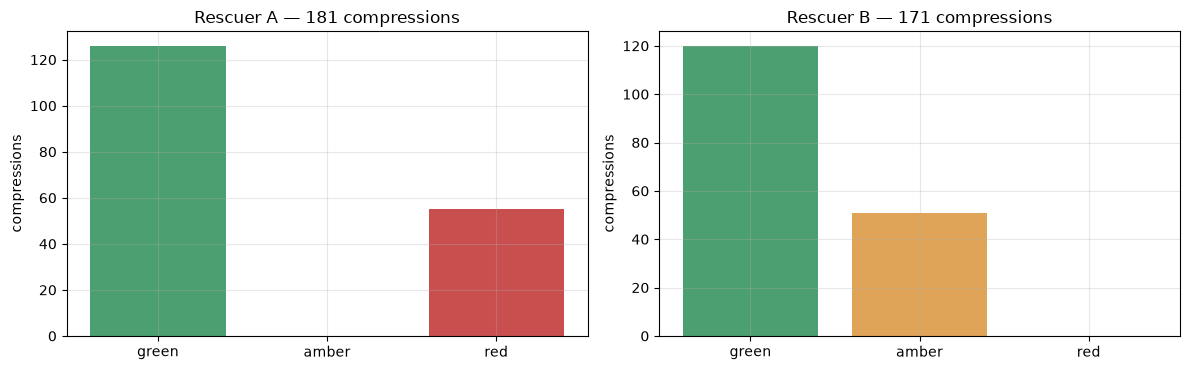

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colours = {"green": "#4c9f70", "amber": "#e0a458", "red": "#c94f4f"}
for ax, who in zip(axes, ["A", "B"]):
    part = comp[comp.rescuer == who]
    counts = part.light.value_counts().reindex(["green", "amber", "red"]).fillna(0)
    ax.bar(counts.index, counts.to_numpy(), color=[colours[c] for c in counts.index])
    ax.set_title(f"Rescuer {who} — {len(part)} compressions")
    ax.set_ylabel("compressions")
plt.tight_layout(); plt.show()

### 5.1 The metronome

The beat is not decoration. Told "press faster", a person speeds up briefly and drifts back;
given a beat to follow, they lock onto it. The unit walks its beat towards the middle of the
guideline range rather than jumping there, because a beat that leaps is one the helper loses.

It starts as close to the helper's own rate as the guideline floor allows — so rescuer B, who
begins at about 96, is met at 100 rather than at 96, and pulled up from there. The beat never
follows the helper down out of range; it is the reference, not a mirror.

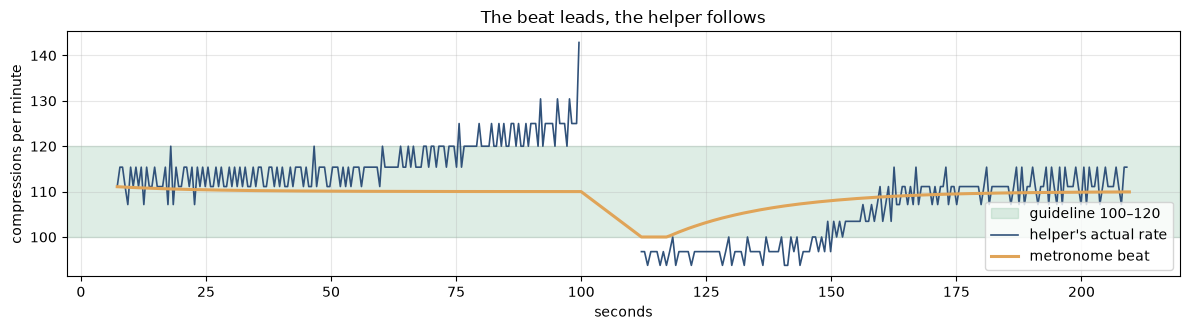

In [15]:
TARGET_CPM = 110

def metronome(rates, target=TARGET_CPM, pull=0.03):
    """Start at the helper's own rate, then walk the beat towards the target.

    Note what this does NOT do: chase the helper. The beat is the reference they
    follow, so it only ever moves towards the target. It starts where they are so
    that the first beat they hear is one they can already match.
    """
    rates = rates.to_numpy()
    beat = np.empty(len(rates))
    current = rates[0] if len(rates) and not np.isnan(rates[0]) else target
    for i in range(len(rates)):
        current += pull * (target - current)
        beat[i] = np.clip(current, RATE_MIN, RATE_MAX)
    return beat


# the beat restarts with each new rescuer - a fresh helper gets met where they are
comp["beat_cpm"] = comp.groupby("rescuer").rate_cpm.transform(metronome)

fig, ax = plt.subplots(figsize=(12, 3.4))
ax.axhspan(RATE_MIN, RATE_MAX, color="#4c9f70", alpha=0.18, label="guideline 100–120")
ax.plot(comp.t, comp.rate_cpm, lw=1.2, color="#31527a", label="helper's actual rate")
ax.plot(comp.t, comp.beat_cpm, lw=2.2, color="#e0a458", label="metronome beat")
ax.set_xlabel("seconds"); ax.set_ylabel("compressions per minute")
ax.set_title("The beat leads, the helper follows")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. Watching the whole session

Individual compressions get individual feedback. Three questions can only be answered by
looking at the session as a whole.

🎬 **See it illustrated:** step 11 — *The Helper Who Cannot Feel It*, step 12 — *Time To Swap*, step 13 — *Hands Off The Chest* in the illustration tab.


### 6.1 Is the helper tiring?

Fatigue does not announce itself. It shows up as a **trend**, and the first attempt at detecting
it fails in a way worth seeing.

The obvious signal is falling depth. Watch what that gives us here.

In [16]:
comp["depth_roll"] = comp.groupby("rescuer").depth_cm.transform(
    lambda s: s.rolling(15, min_periods=5).mean())
comp["stroke_roll"] = comp.groupby("rescuer").stroke_cm.transform(
    lambda s: s.rolling(15, min_periods=5).mean())
comp["rate_roll"] = comp.groupby("rescuer").rate_cpm.transform(
    lambda s: s.rolling(15, min_periods=5).mean())

a = comp[comp.rescuer == "A"]
print("rescuer A, first 20 compressions vs last 20")
print(f"  peak depth : {a.depth_cm.head(20).mean():.2f} cm  →  "
      f"{a.depth_cm.tail(20).mean():.2f} cm   (fell {a.depth_cm.head(20).mean() - a.depth_cm.tail(20).mean():.2f})")
print(f"  stroke     : {a.stroke_cm.head(20).mean():.2f} cm  →  "
      f"{a.stroke_cm.tail(20).mean():.2f} cm   (fell {a.stroke_cm.head(20).mean() - a.stroke_cm.tail(20).mean():.2f})")
print(f"  lean       : {a.residual_cm.head(20).mean():.2f} cm  →  "
      f"{a.residual_cm.tail(20).mean():.2f} cm")

rescuer A, first 20 compressions vs last 20
  peak depth : 5.48 cm  →  4.89 cm   (fell 0.59)
  stroke     : 5.38 cm  →  4.06 cm   (fell 1.32)
  lean       : 0.10 cm  →  0.84 cm


**Peak depth barely moved. The actual compression collapsed.**

As the helper tires they stop coming all the way up, so each push starts from lower down. The
chest still gets pressed to roughly the same depth, and a detector watching peak depth sees
almost nothing wrong — while every push is doing progressively less work.

So fatigue is detected on **`stroke_cm`**, compared against the helper's *own* first twenty
compressions. Comparing against their own baseline matters: an absolute threshold either fires
immediately for a physically small helper or never fires for a strong one.

In [17]:
baseline = comp.groupby("rescuer").stroke_cm.transform(lambda s: s.head(20).mean())
comp["stroke_vs_own_start"] = comp.stroke_roll - baseline
comp["tiring"] = comp.stroke_vs_own_start < -0.5

for who, part in comp.groupby("rescuer"):
    tired = part[part.tiring]
    when = f"{tired.t.iloc[0]:.0f} s ({tired.t.iloc[0] - part.t.iloc[0]:.0f} s in)" if len(tired) else "never"
    print(f"rescuer {who}: baseline stroke {baseline[part.index[0]]:.2f} cm, "
          f"fell 0.5 cm below it at {when}")

rescuer A: baseline stroke 5.38 cm, fell 0.5 cm below it at 71 s (63 s in)
rescuer B: baseline stroke 5.57 cm, fell 0.5 cm below it at never


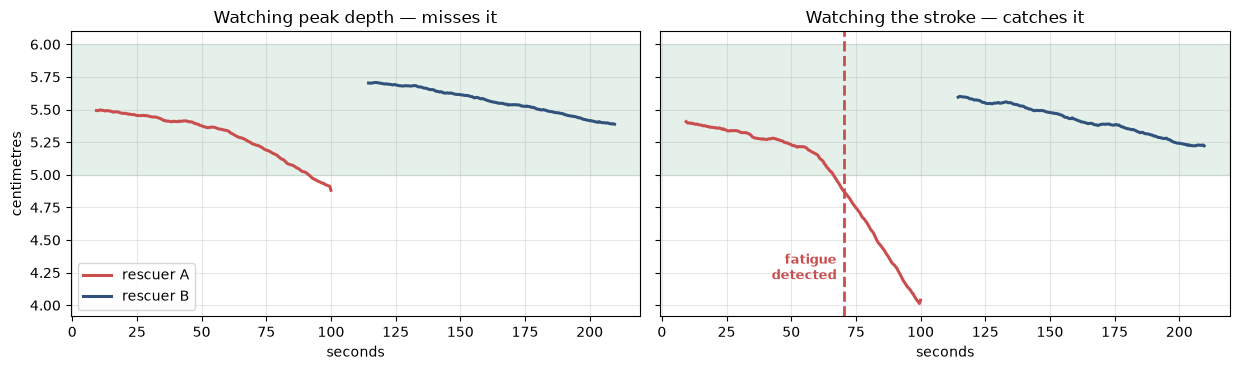

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)
for ax, column, title in ((axes[0], "depth_roll", "Watching peak depth — misses it"),
                          (axes[1], "stroke_roll", "Watching the stroke — catches it")):
    ax.axhspan(DEPTH_MIN, DEPTH_MAX, color="#4c9f70", alpha=0.15)
    for who, colour in (("A", "#c94f4f"), ("B", "#31527a")):
        part = comp[comp.rescuer == who]
        ax.plot(part.t, part[column], lw=2.2, color=colour, label=f"rescuer {who}")
    ax.set_title(title); ax.set_xlabel("seconds")
tired_a = comp[(comp.rescuer == "A") & comp.tiring]
if len(tired_a):
    axes[1].axvline(tired_a.t.iloc[0], color="#c94f4f", ls="--", lw=2)
    axes[1].text(tired_a.t.iloc[0] - 3, 4.2, "fatigue\ndetected", color="#c94f4f",
                 fontweight="bold", ha="right", fontsize=9)
axes[0].set_ylabel("centimetres"); axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

### 6.2 Calling the switch

Guidelines say swap rescuers roughly every two minutes, because quality falls long before the
helper feels tired. The unit asks the second person to **get into position first**, so that the
swap costs a couple of seconds rather than ten — every second with hands off the chest is
blood not moving.

In [19]:
def switch_plan(comp, second_person_available=True):
    """When to warn the standby rescuer, and when to call the swap."""
    events = []
    for who, part in comp.groupby("rescuer"):
        start = part.t.iloc[0]
        tired = part[part.tiring]
        by_clock = start + SWITCH_SECONDS
        by_quality = tired.t.iloc[0] if len(tired) else np.inf
        call = min(by_clock, by_quality)
        if call > part.t.iloc[-1]:
            events.append((who, None, None, "finished before a switch was needed"))
            continue
        reason = "quality falling" if by_quality <= by_clock else "two minutes elapsed"
        if not second_person_available:
            events.append((who, None, call, f"{reason}, but nobody else is here — "
                                            "keep going, do not stop"))
        else:
            events.append((who, max(call - 15, start), call, reason))
    return events


for who, warn, call, reason in switch_plan(comp):
    if warn is None and call is None:
        print(f"rescuer {who}: {reason}")
    elif warn is None:
        print(f"rescuer {who}: {reason} (at {call:.0f} s)")
    else:
        print(f"rescuer {who}: warn the standby at {warn:.0f} s, swap at {call:.0f} s — {reason}")

print()
print("If the helper is alone:")
for who, warn, call, reason in switch_plan(comp, second_person_available=False):
    print(f"  rescuer {who}: {reason}")

rescuer A: warn the standby at 56 s, swap at 71 s — quality falling
rescuer B: finished before a switch was needed

If the helper is alone:
  rescuer A: quality falling, but nobody else is here — keep going, do not stop
  rescuer B: finished before a switch was needed


That second block matters more than it looks. A unit that says *"you are tiring, swap with
someone"* to a person who is completely alone has given an instruction that cannot be followed,
and the only thing it achieves is telling the helper they are failing. When no second person is
visible, the correct output is to keep the beat going and say so.

### 6.3 Hands-off time

The single number most strongly tied to survival is the **chest compression fraction**: the
share of the whole rescue that somebody's hands were actually compressing. Guidelines want at
least 60%, and ideally 80%.

In [20]:
hands_on = compressing.sum() / FS
total = RESCUE_SECONDS
ccf = hands_on / total

print(f"total rescue time     : {total} s")
print(f"hands on the chest    : {hands_on:.0f} s")
print(f"hands off             : {total - hands_on:.0f} s")
print(f"chest compression frac: {ccf:.1%}  ({'meets' if ccf >= 0.6 else 'below'} the 60% floor)")
print()
for start, end in HANDS_OFF:
    print(f"  {end - start:>2.0f} s off at t={start:.0f}s")

total rescue time     : 210 s
hands on the chest    : 191 s
hands off             : 19 s
chest compression frac: 91.0%  (meets the 60% floor)

   7 s off at t=0s
  12 s off at t=100s


### 6.4 The AED, and the one decision the AI must not make

While the AED analyses and delivers a shock, nobody may touch the patient. The coach's job here
is narrow and absolute: **enforce stand-clear, then get hands back on the chest immediately.**

The state machine below has no branch that decides whether to shock. It cannot have one. It
reads the AED's state and coaches around it — and the loudest thing it ever says is *resume*,
because delay after a shock is where rescues are lost.

In [21]:
AED_STATES = {
    "idle":      ("green",  "Keep compressing. Pads on the bare chest when you can."),
    "analysing": ("amber",  "STOP. Hands off. Do not touch the patient."),
    "shock":     ("red",    "STAND CLEAR. Nobody touching the patient."),
    "resume":    ("green",  "Start compressions again NOW — do not wait."),
}

def aed_coach(state, hands_on_patient):
    """Coaching around the AED. Never decides whether to shock."""
    if state not in AED_STATES:
        raise ValueError(f"unknown AED state: {state}")
    light, message = AED_STATES[state]
    if state in ("analysing", "shock") and hands_on_patient:
        return "red", "HANDS OFF NOW — " + message
    return light, message


for state, hands in [("idle", True), ("analysing", True), ("analysing", False),
                     ("shock", False), ("resume", False)]:
    light, message = aed_coach(state, hands)
    print(f"{state:<10} hands_on={str(hands):<5} → [{light:>5}] {message}")

idle       hands_on=True  → [green] Keep compressing. Pads on the bare chest when you can.
analysing  hands_on=True  → [  red] HANDS OFF NOW — STOP. Hands off. Do not touch the patient.
analysing  hands_on=False → [amber] STOP. Hands off. Do not touch the patient.
shock      hands_on=False → [  red] STAND CLEAR. Nobody touching the patient.
resume     hands_on=False → [green] Start compressions again NOW — do not wait.


## 7. The CPR quality timeline

Everything above, on one time axis. This is the picture a paramedic would be handed on arrival,
and the one a trainer would replay afterwards.

🎬 **See it illustrated:** step 15 — *The Picture The Paramedic Gets* in the illustration tab.


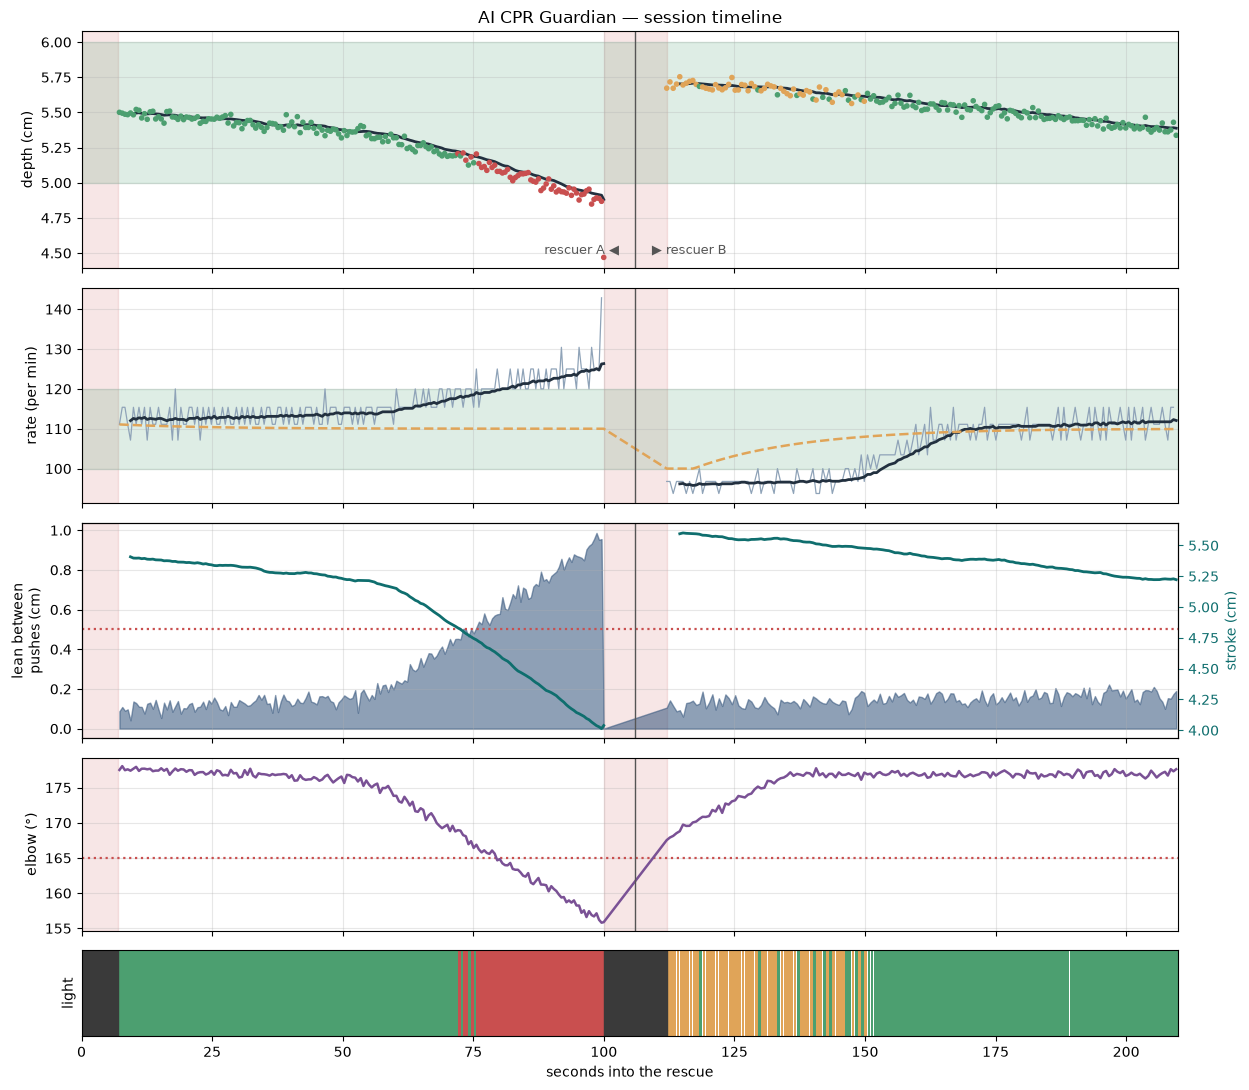

In [22]:
fig, axes = plt.subplots(5, 1, figsize=(12.5, 11), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.2, 2, 2, 1.6, 0.8]))

def mark_pauses(ax):
    for start, end in HANDS_OFF:
        ax.axvspan(start, end, color="#c94f4f", alpha=0.14, zorder=0)

# --- depth
ax = axes[0]
ax.axhspan(DEPTH_MIN, DEPTH_MAX, color="#4c9f70", alpha=0.18)
ax.scatter(comp.t, comp.depth_cm, s=9, c=[colours[c] for c in comp.light], zorder=3)
ax.plot(comp.t, comp.depth_roll, color="#22303f", lw=2)
mark_pauses(ax)
ax.set_ylabel("depth (cm)"); ax.set_title("AI CPR Guardian — session timeline")

# --- rate
ax = axes[1]
ax.axhspan(RATE_MIN, RATE_MAX, color="#4c9f70", alpha=0.18)
ax.plot(comp.t, comp.rate_cpm, lw=0.9, color="#8fa3b8")
ax.plot(comp.t, comp.rate_roll, lw=2, color="#22303f")
ax.plot(comp.t, comp.beat_cpm, lw=1.8, color="#e0a458", ls="--")
mark_pauses(ax)
ax.set_ylabel("rate (per min)")

# --- recoil
ax = axes[2]
ax.axhline(RECOIL_MAX, color="#c94f4f", ls=":", lw=1.6)
ax.fill_between(comp.t, 0, comp.residual_cm, color="#31527a", alpha=0.55)
mark_pauses(ax)
ax.set_ylabel("lean between\npushes (cm)")
ax2 = ax.twinx()          # teal, not red - the red dotted line above is a different scale
ax2.plot(comp.t, comp.stroke_roll, color="#0f6e6e", lw=2)
ax2.set_ylabel("stroke (cm)", color="#0f6e6e")
ax2.tick_params(axis="y", colors="#0f6e6e")
ax2.grid(False)

# --- posture
ax = axes[3]
ax.axhline(165, color="#c94f4f", ls=":", lw=1.6)
ax.plot(comp.t, comp.elbow_deg, lw=1.8, color="#7a5195")
mark_pauses(ax)
ax.set_ylabel("elbow (°)")

# --- the light bar
ax = axes[4]
for _, r in comp.iterrows():
    ax.add_patch(Rectangle((r.t, 0), 0.55, 1, color=colours[r.light], lw=0))
for start, end in HANDS_OFF:
    ax.add_patch(Rectangle((start, 0), end - start, 1, color="#3a3a3a"))
ax.set_xlim(0, RESCUE_SECONDS); ax.set_ylim(0, 1)
ax.set_yticks([]); ax.set_xlabel("seconds into the rescue")
ax.set_ylabel("light"); ax.grid(False)

for ax in axes[:4]:
    ax.axvline(106, color="#555", lw=1)
# axes-fraction coordinates, so the labels cannot escape the panel
axes[0].text(0.49, 0.06, "rescuer A ◀", transform=axes[0].transAxes,
             fontsize=9, color="#555", ha="right")
axes[0].text(0.52, 0.06, "▶ rescuer B", transform=axes[0].transAxes,
             fontsize=9, color="#555")

plt.tight_layout(); plt.show()

In [23]:
report = pd.DataFrame([{
    "rescuer": who,
    "compressions": len(part),
    "mean depth (cm)": part.depth_cm.mean(),
    "mean stroke (cm)": part.stroke_cm.mean(),
    "in-range depth": f"{part.depth_cm.between(DEPTH_MIN, DEPTH_MAX).mean():.0%}",
    "mean rate": part.rate_cpm.mean(),
    "in-range rate": f"{part.rate_cpm.between(RATE_MIN, RATE_MAX).mean():.0%}",
    "full recoil": f"{(part.residual_cm <= RECOIL_MAX).mean():.0%}",
    "green": f"{(part.light == 'green').mean():.0%}",
} for who, part in comp.groupby("rescuer")]).round(2)

print(report.to_string(index=False))
print(f"\nchest compression fraction: {ccf:.1%}")
print(f"total compressions        : {len(comp)}")

rescuer  compressions  mean depth (cm)  mean stroke (cm) in-range depth  mean rate in-range rate full recoil green
      A           181             5.27              4.93            86%     116.71           85%         71%   70%
      B           171             5.55              5.40           100%     105.05           70%        100%   70%

chest compression fraction: 91.0%
total compressions        : 352


## 8. What this would get wrong

An honest list, because a device that coaches a frightened stranger through the worst minutes of
their life earns a harder look than a demo usually gets.

**The data is invented.** Every number on this page came from the generator in section 2. The
generator was written by someone who already knew what the analysis should find. Real helpers
fail in ways nobody thought to simulate.

**The camera is the weakest link.** Section 3 measured elbow angle to within about a degree
*because the keypoints were generated cleanly.* In a real room: the helper's back is to the
camera, a bystander walks through the frame, the patient is on their side in a stairwell, the
lighting is a phone torch. Pose models degrade sharply under exactly those conditions, and none
of it is represented here.

**Thresholds are not people.** 5 cm is guidance for an adult. It is wrong for a child, wrong for
a frail elderly chest, and the unit as written cannot tell the difference. Shouting "press
deeper" at someone compressing an eighty-year-old correctly is an instruction to cause harm.

**A pad has to be placed correctly to measure anything.** Every depth number assumes the pad is
on the sternum and not sliding. A displaced pad reports confident nonsense, and nothing in this
notebook detects that.

**Being told you are getting it wrong has a cost.** A helper who gets a red light every second
may stop altogether. "Keep going, help is on its way" is sometimes the most useful thing the
unit can say — pushing that is not perfect is worth far more than no pushing at all.

**And the boundary that does not move:** the coach never decides about a shock. That belongs to
a regulated AED, and this notebook models only the stand-clear state around it.

🎬 **See it illustrated:** step 16 — *What This Would Get Wrong* in the illustration tab.


## 9. Your turn

1. **Break the pad.** Add a slow drift to `depth` in section 2 (`depth += t * 0.004`) as if the
   pad were slipping. How many compressions does the unit then call "too deep"? Would a human
   notice?
2. **Take the second person away.** Re-run `switch_plan(comp, second_person_available=False)`
   and write the messages the unit should say at 100 s. What is the *right* thing to tell
   somebody who cannot stop?
3. **Change the priority order** in `coach()` so that "straighten your arms" comes first. Recount
   the messages. How many compressions now get posture advice instead of "press deeper"?
4. **Child mode.** Make `DEPTH_MIN`, `DEPTH_MAX` parameters of `coach()` and set them to 4–5 cm.
   Which rescuer's session changes more, and why?
5. **Measure the pauses.** Write the code that finds every gap longer than 2 seconds between
   compressions and reports the chest compression fraction *without* using the `HANDS_OFF`
   list — the real unit does not get told where the pauses are.

### Cheat sheet

```python
# angle at point b, from a-b-c, on arrays of 2-D points
v1, v2 = a - b, c - b
cos = (v1 * v2).sum(1) / (norm(v1, axis=1) * norm(v2, axis=1))
angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))

# peaks: higher than both neighbours, above a floor, not too close together
higher = (x[1:-1] > x[:-2]) & (x[1:-1] >= x[2:])

# per-compression table, then everything is pandas
comp.groupby("rescuer")[["depth_cm", "rate_cpm"]].mean()
comp.groupby("rescuer").depth_cm.transform(lambda s: s.rolling(15).mean())

# trend against a person's OWN baseline, not an absolute threshold
baseline = comp.groupby("rescuer").depth_cm.transform(lambda s: s.head(20).mean())
tiring = comp.depth_roll - baseline < -0.4

# chest compression fraction
ccf = compressing.sum() / len(compressing)
```

**The three sensor rules, one more time:** camera for posture, pad for depth and rate and
recoil, AED for rhythm — and the shock decision is never the AI's.

🎬 **See it illustrated:** step 16 — *What This Would Get Wrong* in the illustration tab.
